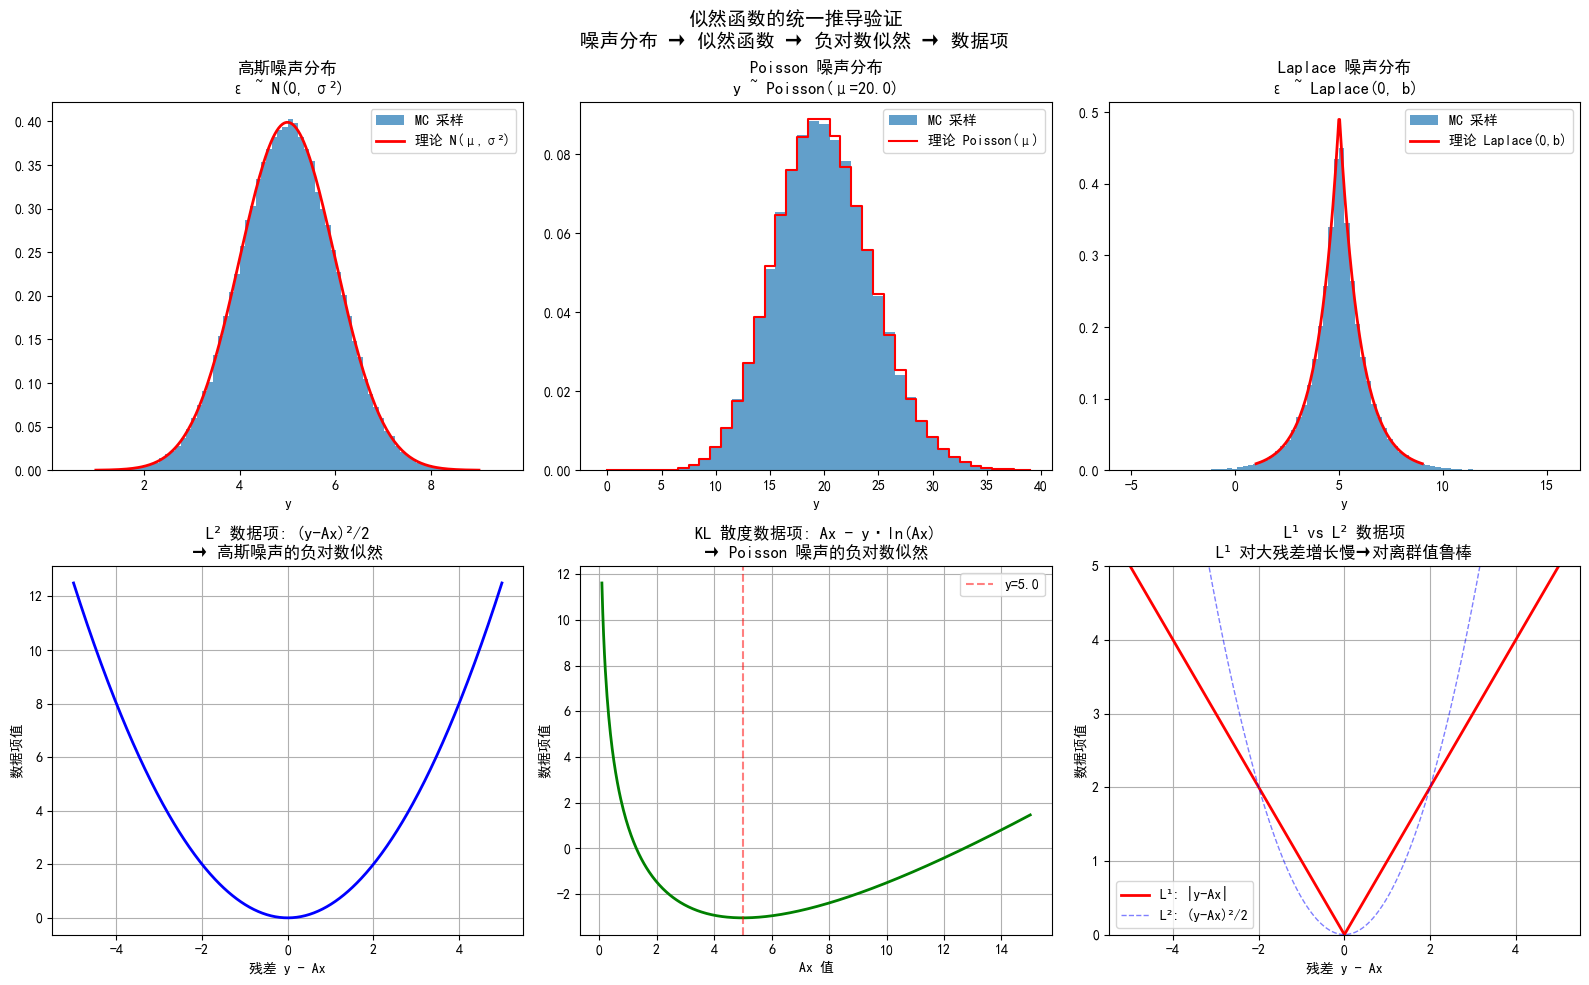

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, laplace, poisson
import matplotlib as mpl

# ====== 解决中文乱码的核心代码 ======
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号
# ========================================================

np.random.seed(42)

# ---- 1. 统一推导框架验证 ----
# 设 Ax = μ（标量），y 为观测值
# 验证：负对数似然 = 数据项（忽略常数）

# (a) 高斯噪声：ε ~ N(0, σ²)
# 似然: p(y|x) = N(y; μ, σ²)
# -ln p(y|x) = (y-μ)²/(2σ²) + const → L² 数据项

# (b) Poisson 噪声：y ~ Poisson(μ)
# 似然: p(y|x) = μ^y e^{-μ} / y!
# -ln p(y|x) = μ - y ln(μ) + const → KL 散度数据项

# (c) Laplace 噪声：ε ~ Laplace(0, b)
# 似然: p(y|x) = (1/2b) exp(-|y-μ|/b)
# -ln p(y|x) = |y-μ|/b + const → L¹ 数据项

# ---- 2. 蒙特卡洛验证：从噪声模型采样，验证似然 ----
n_samples = 100000
mu_true = 5.0  # "Ax" 的值

# (a) 高斯噪声
sigma = 1.0
y_gauss = mu_true + sigma * np.random.randn(n_samples)

# 理论似然在某点 y0 处的值 vs 蒙特卡洛频率
y_test = np.linspace(mu_true - 4, mu_true + 4, 200)
pdf_gauss_theory = norm.pdf(y_test, loc=mu_true, scale=sigma)

# (b) Poisson 噪声
mu_poisson = 20.0
y_poisson = np.random.poisson(mu_poisson, n_samples)

# (c) Laplace 噪声
b = 1.0
y_laplace = mu_true + np.random.laplace(0, b, n_samples)
pdf_laplace_theory = laplace.pdf(y_test, loc=mu_true, scale=b)

# ---- 3. 三种数据项对残差的惩罚曲线 ----
residual = np.linspace(-5, 5, 500)

# L² 数据项
D_L2 = residual ** 2 / 2  # 忽略 σ²

# L¹ 数据项
D_L1 = np.abs(residual)

# KL 散度数据项（Poisson，y=5）
y_obs = 5.0
Ax_range = np.linspace(0.1, 15, 500)
D_KL = Ax_range - y_obs * np.log(Ax_range)

# ---- 4. 可视化 ----
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 第一行：三种噪声的分布
axes[0, 0].hist(y_gauss, bins=80, density=True, alpha=0.7, label='MC 采样')
axes[0, 0].plot(y_test, pdf_gauss_theory, 'r-', linewidth=2, label='理论 N(μ,σ²)')
axes[0, 0].set_title('高斯噪声分布\nε ~ N(0, σ²)')
axes[0, 0].legend()
axes[0, 0].set_xlabel('y')

axes[0, 1].hist(y_poisson, bins=np.arange(0, 40) - 0.5, density=True, alpha=0.7, label='MC 采样')
y_poisson_range = np.arange(0, 40)
axes[0, 1].step(y_poisson_range, poisson.pmf(y_poisson_range, mu_poisson), 'r-', where='mid', label='理论 Poisson(μ)')
axes[0, 1].set_title(f'Poisson 噪声分布\ny ~ Poisson(μ={mu_poisson})')
axes[0, 1].legend()
axes[0, 1].set_xlabel('y')

axes[0, 2].hist(y_laplace, bins=80, density=True, alpha=0.7, label='MC 采样')
axes[0, 2].plot(y_test, pdf_laplace_theory, 'r-', linewidth=2, label='理论 Laplace(0,b)')
axes[0, 2].set_title('Laplace 噪声分布\nε ~ Laplace(0, b)')
axes[0, 2].legend()
axes[0, 2].set_xlabel('y')

# 第二行：三种数据项
axes[1, 0].plot(residual, D_L2, 'b-', linewidth=2)
axes[1, 0].set_title('L² 数据项: (y-Ax)²/2\n→ 高斯噪声的负对数似然')
axes[1, 0].set_xlabel('残差 y - Ax')
axes[1, 0].set_ylabel('数据项值')
axes[1, 0].grid(True)

axes[1, 1].plot(Ax_range, D_KL, 'g-', linewidth=2)
axes[1, 1].axvline(x=y_obs, color='r', linestyle='--', alpha=0.5, label=f'y={y_obs}')
axes[1, 1].set_title('KL 散度数据项: Ax - y·ln(Ax)\n→ Poisson 噪声的负对数似然')
axes[1, 1].set_xlabel('Ax 值')
axes[1, 1].set_ylabel('数据项值')
axes[1, 1].legend()
axes[1, 1].grid(True)

axes[1, 2].plot(residual, D_L1, 'r-', linewidth=2, label='L¹: |y-Ax|')
axes[1, 2].plot(residual, D_L2, 'b--', linewidth=1, alpha=0.5, label='L²: (y-Ax)²/2')
axes[1, 2].set_title('L¹ vs L² 数据项\nL¹ 对大残差增长慢→对离群值鲁棒')
axes[1, 2].set_xlabel('残差 y - Ax')
axes[1, 2].set_ylabel('数据项值')
axes[1, 2].legend()
axes[1, 2].grid(True)
axes[1, 2].set_ylim(0, 5)

plt.suptitle('似然函数的统一推导验证\n噪声分布 → 似然函数 → 负对数似然 → 数据项', fontsize=14)
plt.tight_layout()
plt.savefig('实验1_11_似然函数验证.png', dpi=150, bbox_inches='tight')
plt.show()